# <b>Email Spam Detection & Explainable AI Platform</b>

## <b>EDA SUMMARY</b>

### Objective

The goal of this project is to build an intelligent email spam detection system using Natural Language Processing (NLP) and Machine Learning techniques.

The project aims to:

- Analyze spam and legitimate (ham) messages
- Understand key characteristics of spam messages
- Identify important words driving spam classification
- Prepare clean text data for machine learning models
- Build an explainable spam detection system

---

#### Dataset Information

Dataset Shape:
- Rows: 5,566
- Columns: 3

Target Variable:
- 0 → Ham (Legitimate Message)
- 1 → Spam Message

After preprocessing:
- Text cleaned
- Stopwords removed
- Lemmatization applied
- Ready for NLP feature extraction

#### <b>Step 1: Import the Libraries</b>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
sns.set_style("whitegrid")

#### <b>Step 2: Load Dataset and Overview</b>

##### Dataset Overview

Before performing NLP analysis, we first understand:

- Dataset dimensions
- Missing values
- Data types
- Class distribution

In [2]:
df = pd.read_csv("../data/processed/spam_cleaned.csv")
df.head()
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

print(df['Category'].value_counts())

Shape: (5566, 3)

Columns:
['Category', 'Message', 'CleanMessage']

Missing Values:
Category        0
Message         0
CleanMessage    0
dtype: int64

Data Types:
Category        int64
Message           str
CleanMessage      str
dtype: object
Category
0    4819
1     747
Name: count, dtype: int64


##### Data Cleaning Summary

The dataset originally contained 5,572 messages.

During text preprocessing:
- Converted text to lowercase
- Removed URLs
- Removed punctuation
- Removed numbers
- Removed stopwords
- Applied lemmatization

After cleaning, 6 messages became empty because they contained only stopwords, symbols, or numeric values.

These records represented only 0.11% of the dataset and were removed.

Final dataset size:

- Original Records: 5,572
- Final Records: 5,566

Data quality remains excellent and suitable for NLP modeling.

#### <b>Step 3: Class Distribution</b>

##### Spam vs Ham Distribution

This analysis helps us understand whether the dataset is balanced or imbalanced.

Class imbalance can significantly affect machine learning performance.

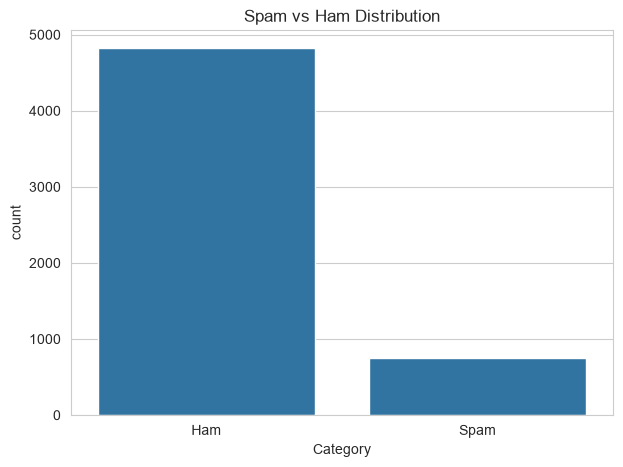

In [3]:
plt.figure(figsize=(7,5))
sns.countplot(x='Category', data=df)
plt.title("Spam vs Ham Distribution")
plt.xticks([0,1],["Ham", "Spam"])
plt.show()

##### Insights

- Ham messages significantly outnumber spam messages.
- Approximately 86% of messages are legitimate.
- Around 14% are spam.
- The dataset is moderately imbalanced and may require attention during model evaluation.

#### <b> Step 4: Message Length Analysis</b>

##### Message Length Analysis

Spam messages often contain more content than legitimate messages.

We analyze the number of characters in each message.

In [4]:
df['MessageLength'] = df["Message"].apply(len)
df.groupby("Category")['MessageLength'].describe()

,count,mean,std,min,25%,50%,75%,max
Category,,,,,,,,
0,4819.0,71.52625,58.428854,2.0,33.0,52.0,93.0,910.0
1,747.0,137.98929,29.980287,7.0,132.0,149.0,157.0,223.0


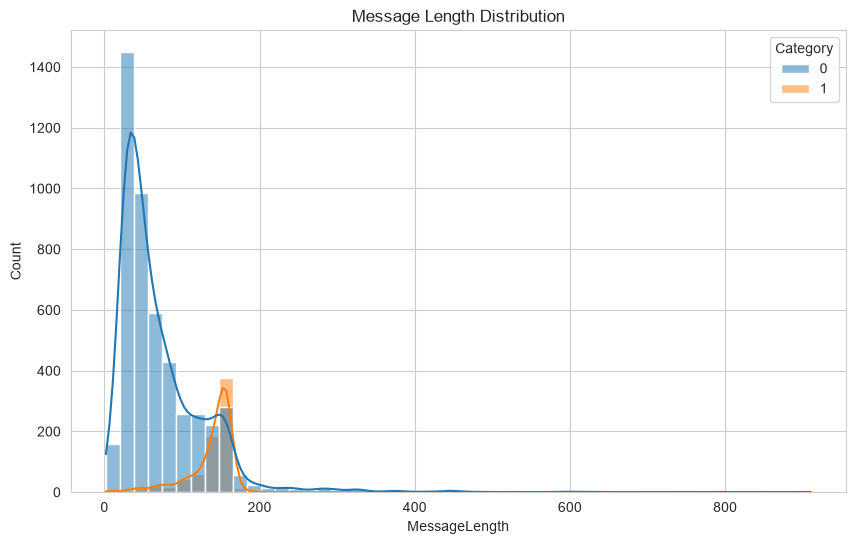

In [5]:
plt.figure(figsize=(10,6))
sns.histplot(
    data=df,
    x="MessageLength",
    hue="Category",
    bins=50,
    kde=True
)
plt.title("Message Length Distribution")
plt.show()

##### Insights

- Spam messages tend to be longer than ham messages.
- Promotional content usually requires more words.
- Message length may become a useful predictive feature.

#### <b>Step 5: Word Count Analysis</b>

##### Word Count Analysis

Word count helps us understand whether spam messages contain more textual content than legitimate messages.

In [6]:
df['WordCount'] = df['Message'].apply(lambda x: len(str(x).split()))
df.groupby('Category')['WordCount'].describe()

,count,mean,std,min,25%,50%,75%,max
Category,,,,,,,,
0,4819.0,14.325171,11.517250,1.0,7.0,11.0,19.0,171.0
1,747.0,23.812584,5.956923,1.0,22.0,25.0,28.0,35.0


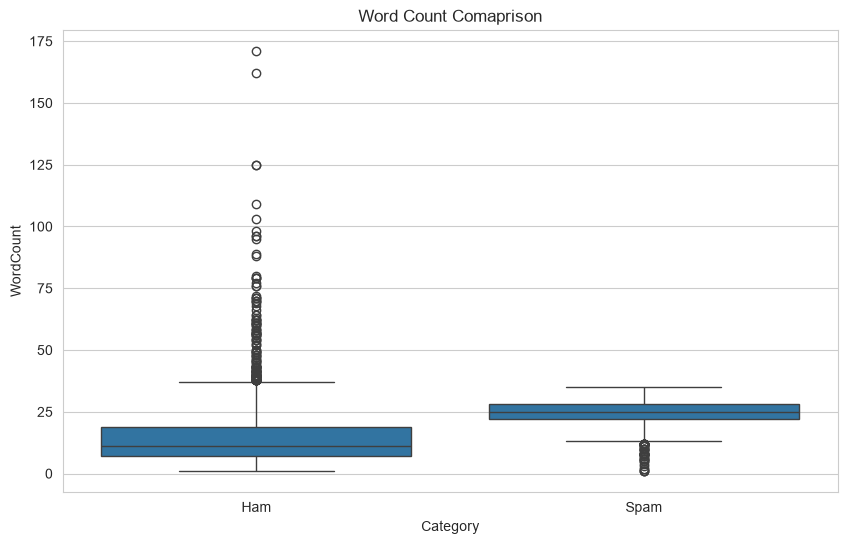

In [7]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Category', y='WordCount', data=df)
plt.xticks([0,1], ['Ham', 'Spam'])
plt.title("Word Count Comaprison")
plt.show()

##### Insights

- Spam messages generally contain more words.
- Spam exhibits greater variability in message size.
- Word count can serve as an additional engineered feature.

#### <b>Step 6: Spam Word Cloud</b>

##### Most Frequent Words in Spam Messages

Word clouds help visualize frequently occurring words in spam communications.

In [8]:
spam_text = " ".join(df[df['Category']==1]['CleanMessage'])
Wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(spam_text)

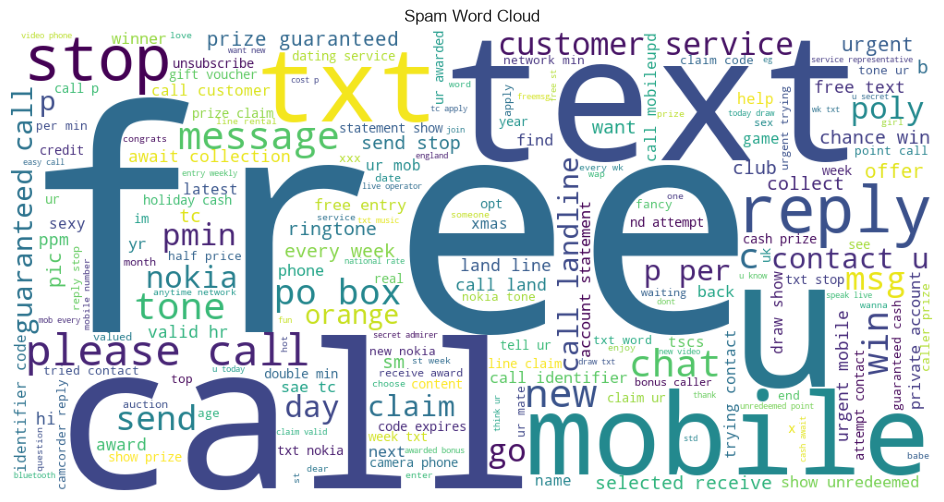

In [9]:
plt.figure(figsize=(15,6))
plt.imshow(Wordcloud)
plt.axis('off')
plt.title("Spam Word Cloud")
plt.show()

##### Insights

Common spam keywords include:
- free
- call
- win
- reply
- claim
- mobile
- txt

These words are strong indicators of promotional or fraudulent content.

#### <b>Step 7: Ham Word Cloud</b>

##### Most Frequent Words in Legitimate Messages

Analyze common words appearing in non-spam messages.

In [10]:
ham_text = " ".join(df[df['Category']==0]['CleanMessage'])
ham_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(ham_text)

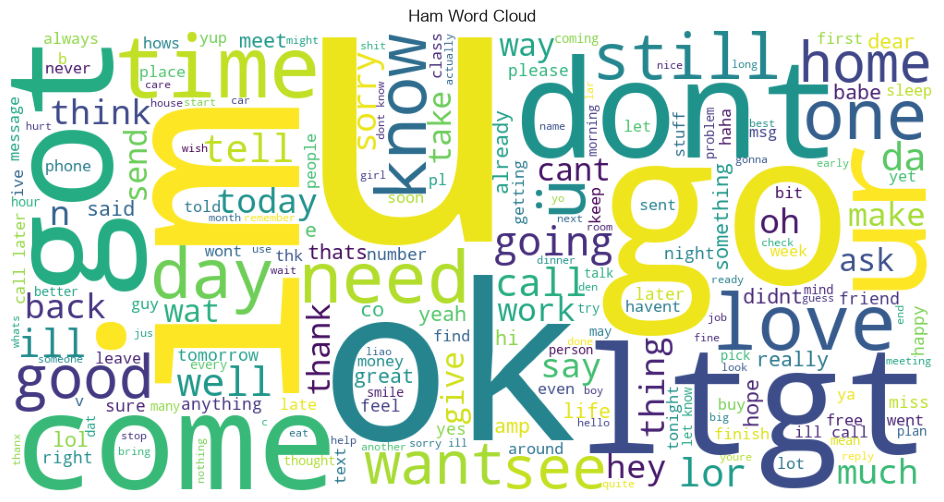

In [11]:
plt.figure(figsize=(15,6))
plt.imshow(ham_wordcloud)
plt.axis('off')
plt.title("Ham Word Cloud")
plt.show()

##### Insights

Ham messages primarily contain:

- personal conversations
- scheduling discussions
- casual communication

The vocabulary differs significantly from spam messages.

#### <b>Step 8: Top 20 Spam Keywords

##### Top Spam Keywords

Identify the most frequently occurring words in spam messages.

In [12]:
from collections import Counter
spam_words = []

for text in df[df['Category']==1]['CleanMessage']:
    spam_words.extend(text.split())

spam_freq = Counter(spam_words)

top_spam = pd.DataFrame(
    spam_freq.most_common(20), columns=['Word','Count']
)

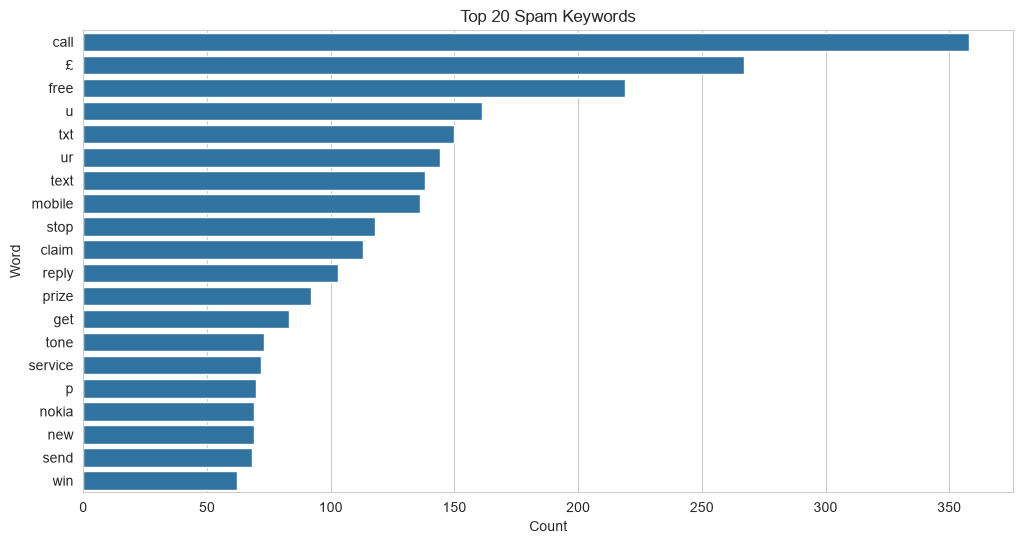

In [13]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=top_spam,
    x='Count',
    y='Word'
)
plt.title("Top 20 Spam Keywords")
plt.show()

##### Insights

The most influential spam words represent:

- financial incentives
- promotions
- rewards
- urgency

These patterns indicate strong linguistic signals that machine learning models can leverage.

#### <b>CONCLUSION</b>

##### Summary

Key findings from the exploratory analysis:

##### Dataset Characteristics

- 5,572 messages analyzed
- Handle missing values
- Binary classification problem

##### Spam Behavior

- Spam messages are generally longer
- Spam contains more words
- Promotional language dominates spam content

##### NLP Findings

Strong spam indicators include:

- free
- win
- call
- reply
- claim

## <b>FEATURE ENGINNERING & NLP VECTORIZATION

### Objective

Machine Learning models cannot directly understand text.

In this step:

- Create additional numerical text features
- Convert cleaned text into TF-IDF vectors
- Prepare model-ready dataset
- Save trained TF-IDF vectorizer

### Why TF-IDF?

TF-IDF (Term Frequency–Inverse Document Frequency):

- Captures important words
- Reduces importance of common words
- Produces sparse numerical vectors
- Works extremely well for spam detection

Expected Output:

- Feature engineered dataset
- Saved TF-IDF vectorizer
- Model-ready features

#### <b> Step 1: Load the Featured Data</b>

In [14]:
featured_df = pd.read_csv("../data/processed/spam_featured.csv")
print(featured_df.shape)
print(featured_df.columns[:10])
print(featured_df.isnull().sum().sum())

(5566, 3005)
Index(['Category', 'CharCount', 'WordCount', 'SentenceCount', 'AvgWordLength',
       'aah', 'aathilove', 'aathiwhere', 'abi', 'ability'],
      dtype='str')
0


#### <b>Feature Engineering Validation</b>

Analyze newly created text features before model training.

#### <b> Step 2: Character Count Distribution

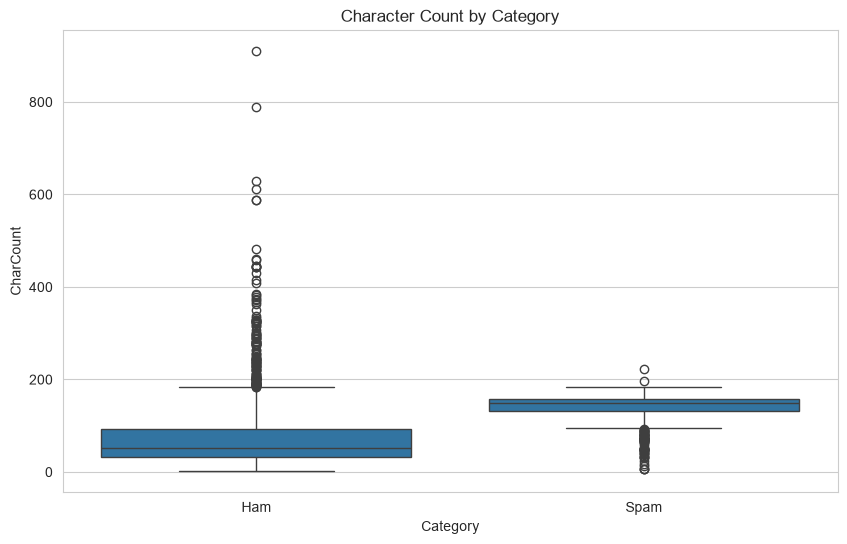

In [15]:
plt.figure(figsize=(10,6))
sns.boxplot(
    x="Category",
    y="CharCount",
    data=featured_df
)
plt.xticks([0,1], ['Ham', 'Spam'])
plt.title("Character Count by Category")
plt.show()

##### Insights

Spam messages generally contain more characters than legitimate messages.

Longer messages often indicate promotional content, offers, or advertisements.

#### <b>Step 3: Word Count Distribution</b>

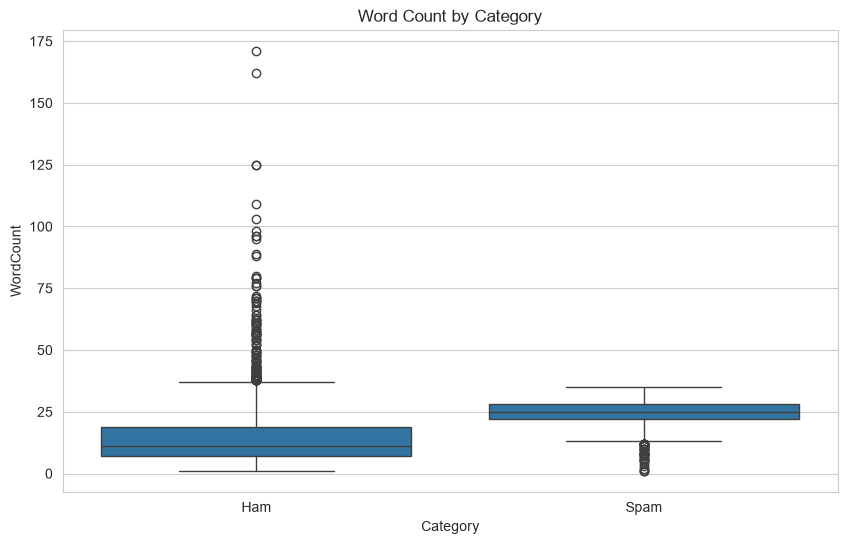

In [16]:
plt.figure(figsize=(10,6))
sns.boxplot(
    x='Category',
    y='WordCount',
    data=df
)
plt.xticks([0,1],['Ham','Spam'])
plt.title("Word Count by Category")
plt.show()

##### Insights

Spam messages contain significantly more words on average.

Word count appears to be a useful predictor for spam detection.

#### <b> CONCLUSION</b>

##### Summary
The dataset was successfully transformed into machine-learning-ready numerical features.

TF-IDF converted text into approximately 3000 numerical features while preserving the importance of informative words.

Additional engineered features such as character count and word count provide extra signals for spam classification.

Created Features:

- Character Count
- Word Count
- Sentence Count
- Average Word Length

TF-IDF Vectorization:

- Top 3000 vocabulary terms
- Sparse numerical representation
- Saved vectorizer for production deployment

Output Files:

- spam_featured.csv
- tfidf_vectorizer.pkl

Next Step:

Model Preparation & Train/Test Split